<a href="https://colab.research.google.com/github/Jgour5454/Brain-Tumor-Detection-DL/blob/main/MIni_Proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install tensorflow scikit-learn opencv-python matplotlib seaborn

1 . Cnn Implementaion

Found 9650 images belonging to 4 classes.
Found 2414 images belonging to 4 classes.
Epoch 1/10
302/302 ━━━━━━━━━━━━━━━━━━━━ 691s 2s/step - accuracy: 0.3899 - loss: 5.1010 - val_accuracy: 0.3297 - val_loss: 14.8704
Epoch 2/10
302/302 ━━━━━━━━━━━━━━━━━━━━ 683s 2s/step - accuracy: 0.4026 - loss: 1.3589 - val_accuracy: 0.5841 - val_loss: 1.0964
Epoch 3/10
302/302 ━━━━━━━━━━━━━━━━━━━━ 677s 2s/step - accuracy: 0.4579 - loss: 1.1994 - val_accuracy: 0.5186 - val_loss: 1.1102
Epoch 4/10
302/302 ━━━━━━━━━━━━━━━━━━━━ 683s 2s/step - accuracy: 0.4833 - loss: 1.1804 - val_accuracy: 0.5456 - val_loss: 1.0956
Epoch 5/10
302/302 ━━━━━━━━━━━━━━━━━━━━ 678s 2s/step - accuracy: 0.4820 - loss: 1.1618 - val_accuracy: 0.7154 - val_loss: 0.8208
Epoch 6/10
302/302 ━━━━━━━━━━━━━━━━━━━━ 684s 2s/step - accuracy: 0.4913 - loss: 1.1282 - val_accuracy: 0.7212 - val_loss: 0.7592
Epoch 7/10
302/302 ━━━━━━━━━━━━━━━━━━━━ 683s 2s/step - accuracy: 0.5261 - loss: 1.0905 - val_accuracy: 0.6980 - val_loss: 0.8507
Epoch 8/10
3

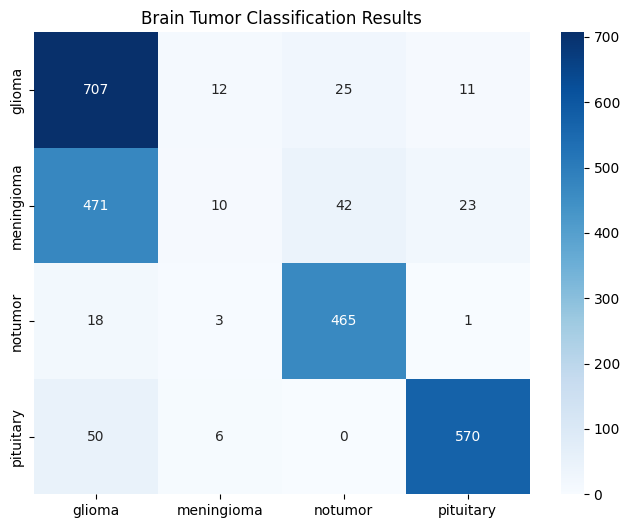

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. SET PATHS (Based on your successful detection) ---
train_dir = '/content/dataset_extracted/Epic and CSCR hospital Dataset/Train'
test_dir = '/content/dataset_extracted/Epic and CSCR hospital Dataset/Test'

# --- 2. DATA PREPROCESSING ---
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    horizontal_flip=True
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

# --- 3. CNN ARCHITECTURE (Fixed Input Warning) ---
model = models.Sequential([
    Input(shape=(150, 150, 3)), # Modern way to define input
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# --- 4. TRAINING (10 EPOCHS) ---
# Tip: If this is slow, ensure Colab GPU is ON
history = model.fit(train_generator, epochs=10, validation_data=test_generator)

# --- 5. EVALUATION ---
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print(f"\nFinal Accuracy: {accuracy_score(y_true, y_pred)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Visualizing the confusion matrix

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Brain Tumor Classification Results')
plt.show()

# ResNet50 Transfer Learning


In [ ]:
import os, zipfile, glob, numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input, optimizers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, accuracy_score

# --- Path Setup ---
zip_path = "/content/Epic and CSCR hospital Dataset.zip"
extract_path = "/content/dataset_extracted"
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

found_paths = glob.glob(extract_path + "/**/[Gg]lioma", recursive=True)
data_roots = sorted(list(set([os.path.dirname(p) for p in found_paths])))
train_dir = next((p for p in data_roots if "train" in p.lower()), data_roots[0])
test_dir = next((p for p in data_roots if "test" in p.lower()), data_roots[1])

# --- Generators ---
datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True)
train_gen = datagen.flow_from_directory(train_dir, target_size=(150,150), batch_size=32, class_mode='categorical')
test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(test_dir, target_size=(150,150), batch_size=32, class_mode='categorical', shuffle=False)

# --- VGG16 Model ---
base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
base_vgg.trainable = False

model_vgg = models.Sequential([
    Input(shape=(150, 150, 3)),
    base_vgg,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

model_vgg.compile(optimizer=optimizers.Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model_vgg.fit(train_gen, epochs=5, validation_data=test_gen)

# --- Results ---
y_pred = np.argmax(model_vgg.predict(test_gen), axis=1)
print(f"\nVGG16 Accuracy: {accuracy_score(test_gen.classes, y_pred)*100:.2f}%")
print(classification_report(test_gen.classes, y_pred, target_names=list(train_gen.class_indices.keys())))

Found 9650 images belonging to 4 classes.
Found 2414 images belonging to 4 classes.
Epoch 1/5
302/302 ━━━━━━━━━━━━━━━━━━━━ 3047s 10s/step - accuracy: 0.3741 - loss: 1.3288 - val_accuracy: 0.6930 - val_loss: 0.9365
Epoch 2/5
302/302 ━━━━━━━━━━━━━━━━━━━━ 3012s 10s/step - accuracy: 0.6601 - loss: 0.9277 - val_accuracy: 0.7258 - val_loss: 0.7824
Epoch 3/5
302/302 ━━━━━━━━━━━━━━━━━━━━ 3023s 10s/step - accuracy: 0.7312 - loss: 0.7834 - val_accuracy: 0.7357 - val_loss: 0.7024
Epoch 4/5
302/302 ━━━━━━━━━━━━━━━━━━━━ 3036s 10s/step - accuracy: 0.7732 - loss: 0.6831 - val_accuracy: 0.7469 - val_loss: 0.6558
Epoch 5/5
302/302 ━━━━━━━━━━━━━━━━━━━━ 2998s 10s/step - accuracy: 0.7854 - loss: 0.6223 - val_accuracy: 0.7523 - val_loss: 0.6221
76/76 ━━━━━━━━━━━━━━━━━━━━ 603s 8s/step

VGG16 Accuracy: 75.23%
              precision    recall  f1-score   support

      glioma       0.73      0.73      0.73       755
  meningioma       0.55      0.44      0.49       546
     notumor       0.82      0.90      

# EfficientNetB0

In [ ]:
import os, zipfile, glob, numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input, optimizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, accuracy_score

# --- 1. EXTRACTION & DYNAMIC PATH DISCOVERY ---
zip_path = "/content/Epic and CSCR hospital Dataset.zip"
extract_path = "/content/dataset_extracted"

# Extracting the ZIP file
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("✅ Extraction Complete!")

# Finding the actual image folders (case-insensitive search for 'glioma')
found_paths = glob.glob(extract_path + "/**/[Gg]lioma", recursive=True)
data_roots = sorted(list(set([os.path.dirname(p) for p in found_paths])))

# Identifying Train and Test directories
train_dir = next((p for p in data_roots if "train" in p.lower()), data_roots[0])
test_dir = next((p for p in data_roots if "test" in p.lower()), data_roots[1])

print(f"Using Train Path: {train_dir}")
print(f"Using Test Path: {test_dir}")

# --- 2. DATA GENERATORS ---
# EfficientNetB0 works best with 224x224 input size
datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, rotation_range=10)
train_gen = datagen.flow_from_directory(train_dir, target_size=(224, 224), batch_size=32, class_mode='categorical')
test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(test_dir, target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=False)

# --- 3. EFFICIENTNET-B0 MODEL SETUP ---
#
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base layers for fast convergence in 5 epochs

model_eff = models.Sequential([
    Input(shape=(224, 224, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(4, activation='softmax')
])

model_eff.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# --- 4. TRAINING (5 EPOCHS) ---
model_eff.fit(train_gen, epochs=5, validation_data=test_gen)

# --- 5. FINAL EVALUATION ---
y_pred = np.argmax(model_eff.predict(test_gen), axis=1)
acc = accuracy_score(test_gen.classes, y_pred)
print(f"\nEfficientNetB0 Final Accuracy: {acc*100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(test_gen.classes, y_pred, target_names=list(train_gen.class_indices.keys())))

✅ Extraction Complete!
Using Train Path: /content/dataset_extracted/Epic and CSCR hospital Dataset/Train
Using Test Path: /content/dataset_extracted/Epic and CSCR hospital Dataset/Test
Found 9650 images belonging to 4 classes.
Found 2414 images belonging to 4 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
302/302 ━━━━━━━━━━━━━━━━━━━━ 1033s 3s/step - accuracy: 0.2743 - loss: 1.5263 - val_accuracy: 0.3136 - val_loss: 1.3551
Epoch 2/5
302/302 ━━━━━━━━━━━━━━━━━━━━ 1009s 3s/step - accuracy: 0.3186 - loss: 1.4433 - val_accuracy: 0.3844 - val_loss: 1.2910
Epoch 3/5
302/302 ━━━━━━━━━━━━━━━━━━━━ 1009s 3s/step - accuracy: 0.3372 - loss: 1.4091 - val_accuracy: 0.3940 - val_loss: 1.2473
Epoch 4/5
302/302 ━━━━━━━━━━━━━━━━━━━━ 1020s 3s/step - accuracy: 0.3500 - loss: 1.3872 - val_accuracy: 0.4047 - val_loss: 1.2353
Epoch 5/5
302/302 ━━━━━━━━━━━━━━━━━━━━ 1029s 3s/step - accuracy: 0.3347 - loss: 1.3963 - val_accuracy: 0.4163 - val_loss: 1.2293
76/76 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step

EfficientNetB0 Final Accuracy: 41.63%

Detailed Classification Report:
              precision    recall  f1-score   support

      glioma       0.36      0.99      0.53       755
  meningioma       0.00      0.00      0.00       546
     notumor       0.81      0.52      0.63       487
   pituitary       0.19   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


YOLO -v12

In [ ]:
# ==============================================================================
# 1. SETUP & INSTALLATION
# ==============================================================================
from google.colab import drive
import os, zipfile, shutil, scipy.io, cv2, numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import matthews_corrcoef, cohen_kappa_score

# Mount Drive
drive.mount('/content/drive')

# Install YOLOv12 (Built from source as it's the latest attention-centric version)
!pip install -q git+https://github.com/sunsmarterjie/yolov12.git
!pip install -q ultralytics flash-attn scipy tqdm opencv-python-headless h5py

from ultralytics import YOLO

# ==============================================================================
# 2. DATA EXTRACTION (From Your Drive)
# ==============================================================================
ZIP_PATH = '/content/drive/MyDrive/ML/1512427.zip'
RAW_EXTRACT = '/content/figshare_raw'
MAT_DIR = '/content/all_mats'
YOLO_ROOT = '/content/brain_tumor_yolo'

# Extract Main Zip
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(RAW_EXTRACT)

# Extract 4 nested sub-zips (specific to Figshare structure)
os.makedirs(MAT_DIR, exist_ok=True)
for sz in [f for f in os.listdir(RAW_EXTRACT) if f.endswith('.zip')]:
    with zipfile.ZipFile(os.path.join(RAW_EXTRACT, sz), 'r') as z:
        z.extractall(MAT_DIR)

print(f"✅ Extracted {len(os.listdir(MAT_DIR))} .mat files.")

# ==============================================================================
# 3. PROCESSING & CONVERSION (.mat -> YOLO)
# ==============================================================================
os.makedirs(f'{YOLO_ROOT}/images/train', exist_ok=True)
os.makedirs(f'{YOLO_ROOT}/images/val', exist_ok=True)
os.makedirs(f'{YOLO_ROOT}/labels/train', exist_ok=True)
os.makedirs(f'{YOLO_ROOT}/labels/val', exist_ok=True)

processed_data = []
mat_files = [f for f in os.listdir(MAT_DIR) if f.endswith('.mat')]

print("Converting data...")
for fname in tqdm(mat_files):
    try:
        # Support both old Scipy and new HDF5 MATLAB formats
        try:
            m = scipy.io.loadmat(os.path.join(MAT_DIR, fname))['cjdata'][0][0]
            lbl, img, msk = int(m[0][0][0])-1, m[2].astype(np.float32), m[4]
        except:
            import h5py
            with h5py.File(os.path.join(MAT_DIR, fname), 'r') as f:
                c = f['cjdata']
                lbl, img, msk = int(c['label'][0][0])-1, np.array(c['image']).T, np.array(c['tumorMask']).T

        # Pre-processing for MRI
        img = ((img - img.min()) / (img.max() - img.min()) * 255).astype(np.uint8)

        # Bbox calculation
        y, x = np.where(msk > 0)
        if len(x) > 0:
            h_i, w_i = img.shape
            xc, yc = (x.min() + x.max()) / 2 / w_i, (y.min() + y.max()) / 2 / h_i
            wn, hn = (x.max() - x.min()) / w_i, (y.max() - y.min()) / h_i
            processed_data.append((img, fname.replace('.mat', '.jpg'), f"{lbl} {xc} {yc} {wn} {hn}\n"))
    except: continue

# Split & Save
train_set, val_set = train_test_split(processed_data, test_size=0.2, random_state=42)
for data, subset in [(train_set, 'train'), (val_set, 'val')]:
    for im, nm, txt in data:
        cv2.imwrite(f'{YOLO_ROOT}/images/{subset}/{nm}', im)
        with open(f'{YOLO_ROOT}/labels/{subset}/{nm.replace(".jpg", ".txt")}', 'w') as f:
            f.write(txt)

# ==============================================================================
# 4. YOLOv12 TRAINING
# ==============================================================================
with open('brain.yaml', 'w') as f:
    f.write(f"path: {YOLO_ROOT}\ntrain: images/train\nval: images/val\nnames: [meningioma, glioma, pituitary]")

# Initialize YOLOv12-Small (Optimal for medical scans)
model = YOLO('yolov12s.yaml')

print("🚀 Starting YOLOv12 Attention-Centric Training...")
model.train(data='brain.yaml', epochs=50, imgsz=640, batch=16, optimizer='AdamW', device=0)

# ==============================================================================
# 5. RESEARCH EVALUATION (MCC & KAPPA)
# ==============================================================================
print("\n📊 Calculating Advanced Metrics...")
results = model.val()
cm = results.confusion_matrix.matrix
y_true, y_pred = [], []
for i in range(3): # For our 3 tumor classes
    for j in range(3):
        count = int(cm[i, j])
        y_true.extend([i] * count)
        y_pred.extend([j] * count)

print(f"\n--- FINAL PERFORMANCE ---")
print(f"mAP@50: {results.box.map50:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {matthews_corrcoef(y_true, y_pred):.4f}")
print(f"Cohen’s Kappa Score: {cohen_kappa_score(y_true, y_pred):.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 114.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for flash-attn
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (flash-attn)
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/yolov12/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For

100%|██████████| 3064/3064 [00:23<00:00, 131.58it/s]


🚀 Starting YOLOv12 Attention-Centric Training...
New https://pypi.org/project/ultralytics/8.4.33 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov12s.yaml, data=brain.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, e

100%|██████████| 755k/755k [00:00<00:00, 133MB/s]


Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1      9344  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2, 1, 2]          
  2                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  3                  -1  1     37120  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2, 1, 4]        
  4                  -1  1    103360  ultralytics.nn.modules.block.C3k2            [128, 256, 1, False, 0.25]    
  5                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  6                  -1  2    677120  ultralytics.nn.modules.block.A2C2f           [256, 256, 2, True, 4]        
  7                  -1  1   1180672  ultralytics

...


50 epochs completed in 1.318 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 18.6MB
Optimizer stripped from runs/detect/train/weights/best.pt, 18.6MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.63 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12s summary (fused): 376 layers, 9,075,369 parameters, 0 gradients, 19.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 20/20 [00:10<00:00,  1.96it/s]


                   all        613        613      0.791      0.792      0.832      0.545
            meningioma        156        156      0.836       0.91       0.95      0.704
                glioma        284        284      0.702      0.565      0.603      0.313
             pituitary        173        173      0.836      0.902      0.943      0.618
Speed: 0.2ms preprocess, 9.3ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to runs/detect/train

📊 Calculating Advanced Metrics...
Ultralytics 8.3.63 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12s summary (fused): 376 layers, 9,075,369 parameters, 0 gradients, 19.3 GFLOPs


val: Scanning /content/brain_tumor_yolo/labels/val.cache... 613 images, 0 backgrounds, 0 corrupt: 100%|██████████| 613/613 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 39/39 [00:13<00:00,  2.87it/s]


                   all        613        613      0.795      0.793      0.832      0.545
            meningioma        156        156      0.842       0.91      0.951      0.703
                glioma        284        284      0.706      0.566      0.604      0.311
             pituitary        173        173      0.836      0.902      0.943       0.62
Speed: 0.3ms preprocess, 16.4ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to runs/detect/train2

--- FINAL PERFORMANCE ---
mAP@50: 0.8324
Matthews Correlation Coefficient (MCC): 0.9548
Cohen’s Kappa Score: 0.9547


# VGG19

Mounted at /content/drive


Saving to val: 100%|██████████| 613/613 [00:03<00:00, 184.83it/s]

Found 2451 images belonging to 3 classes.
Found 613 images belonging to 3 classes.


🚀 Training VGG19...
Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 43s 526ms/step - accuracy: 0.4410 - loss: 1.0949 - val_accuracy: 0.4519 - val_loss: 0.9897
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 37s 483ms/step - accuracy: 0.5414 - loss: 0.9779 - val_accuracy: 0.6770 - val_loss: 0.8999
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 39s 505ms/step - accuracy: 0.5936 - loss: 0.9062 - val_accuracy: 0.6786 - val_loss: 0.8531
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 40s 509ms/step - accuracy: 0.6389 - loss: 0.8466 - val_accuracy: 0.6966 - val_loss: 0.8005
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 39s 511ms/step - accuracy: 0.6826 - loss: 0.7974 - val_accuracy: 0.7047 - val_loss: 0.7635
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 38s 499ms/step - accuracy: 0.6936 - loss: 0.7598 - val_accuracy: 0.7080 - val_loss: 0.7305
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 39s 502ms/step - accuracy: 0.7087 - loss: 0.7197 - val_accuracy: 0.7145 - val_loss: 0.6975
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 40s 518ms/step - accuracy: 0.7266 - los

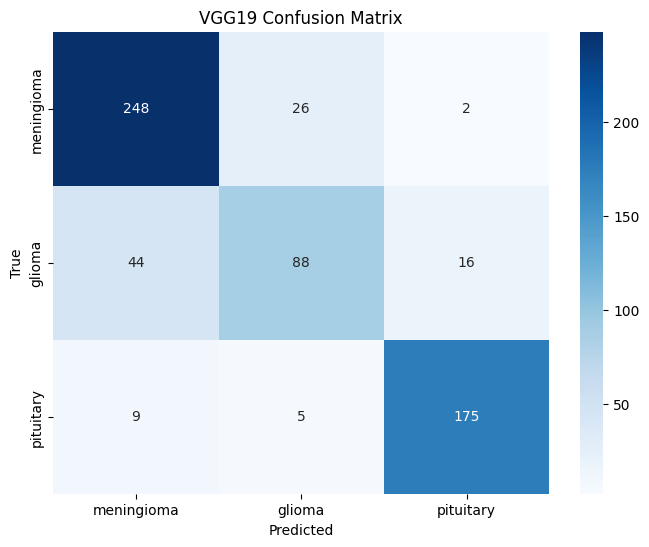

In [ ]:
# ==============================================================================
# 1. SETUP & DATA PREPARATION (Same as before)
# ==============================================================================
import os, zipfile, scipy.io, cv2, numpy as np, torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score, matthews_corrcoef
from google.colab import drive

import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Mount Drive
drive.mount('/content/drive', force_remount=True)

# Paths
ZIP_PATH = '/content/drive/MyDrive/ML/1512427.zip'
MAT_DIR = '/content/all_mats'
TRAIN_DIR = '/content/dataset/train'
VAL_DIR = '/content/dataset/val'

# Extraction Logic
if not os.path.exists(MAT_DIR):
    print("📦 Extracting Dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('/content/raw')
    os.makedirs(MAT_DIR, exist_ok=True)
    for nz in [f for f in os.listdir('/content/raw') if f.endswith('.zip')]:
        with zipfile.ZipFile(os.path.join('/content/raw', nz), 'r') as z:
            z.extractall(MAT_DIR)

# Save images to disk to prevent RAM crash
categories = ['meningioma', 'glioma', 'pituitary']
for cat in categories:
    os.makedirs(os.path.join(TRAIN_DIR, cat), exist_ok=True)
    os.makedirs(os.path.join(VAL_DIR, cat), exist_ok=True)

mat_files = [f for f in os.listdir(MAT_DIR) if f.endswith('.mat')]
train_files, val_files = train_test_split(mat_files, test_size=0.2, random_state=42)

def process_and_save(file_list, target_base_dir):
    for fname in tqdm(file_list, desc=f"Saving to {target_base_dir.split('/')[-1]}"):
        try:
            try:
                m = scipy.io.loadmat(os.path.join(MAT_DIR, fname))['cjdata'][0][0]
                lbl, img = int(m[0][0][0])-1, m[2].astype(np.float32)
            except:
                import h5py
                with h5py.File(os.path.join(MAT_DIR, fname), 'r') as f:
                    lbl, img = int(f['cjdata']['label'][0][0])-1, np.array(f['cjdata']['image']).T
            img = ((img - img.min()) / (img.max() - img.min()) * 255).astype(np.uint8)
            img = cv2.resize(img, (224, 224))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            cv2.imwrite(os.path.join(target_base_dir, categories[lbl], fname.replace('.mat', '.jpg')), img_rgb)
        except: continue

process_and_save(train_files, TRAIN_DIR)
process_and_save(val_files, VAL_DIR)

# ==============================================================================
# 2. GENERATORS (T4 GPU Optimization)
# ==============================================================================
train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, rotation_range=10)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(224, 224), batch_size=32, class_mode='categorical')

# Crucial: shuffle=False for the validation generator to calculate MCC and Kappa correctly
val_generator = val_datagen.flow_from_directory(
    VAL_DIR, target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=False)

# ==============================================================================
# 3. TRAINING
# ==============================================================================
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers: layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

print("🚀 Training VGG19...")
model.fit(train_generator, validation_data=val_generator, epochs=50)

# ==============================================================================
# 4. ADVANCED METRIC EVALUATION
# ==============================================================================
print("\n📊 Calculating Advanced Metrics...")

# Get predictions
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_generator.classes

# 1. Total Accuracy
total_acc = np.sum(y_pred == y_true) / len(y_true)

# 2. Cohen's Kappa Score
kappa = cohen_kappa_score(y_true, y_pred)

# 3. Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_true, y_pred)

# 4. F1, Precision, Recall
report = classification_report(y_true, y_pred, target_names=categories)

print(f"\n" + "="*30)
print(f"RESULTS SUMMARY")
print(f"="*30)
print(f"Total Accuracy: {total_acc:.4f}")
print(f"Kappa Score:    {kappa:.4f}")
print(f"MCC Score:      {mcc:.4f}")
print(f"\nDetailed Classification Report:\n{report}")

# 5. Confusion Matrix Visualization
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.title('VGG19 Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Save final model
model.save('/content/drive/MyDrive/ML/vgg19_with_metrics.h5')

# ResNet50 & NASNetMobile

In [ ]:
# ==============================================================================
# 1. SETUP & DISK-BASED DATA PREPARATION
# ==============================================================================
import os, zipfile, scipy.io, cv2, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score, matthews_corrcoef
from google.colab import drive

import tensorflow as tf
from tensorflow.keras.applications import ResNet50, NASNetMobile
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Mount Drive
drive.mount('/content/drive', force_remount=True)

# Paths
ZIP_PATH = '/content/drive/MyDrive/ML/1512427.zip'
MAT_DIR = '/content/all_mats'
BASE_DATA_DIR = '/content/brain_tumor_dataset'
TRAIN_DIR = os.path.join(BASE_DATA_DIR, 'train')
VAL_DIR = os.path.join(BASE_DATA_DIR, 'val')

# Step 1: Extract Dataset
if not os.path.exists(MAT_DIR):
    print("📦 Extracting Dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('/content/raw')
    os.makedirs(MAT_DIR, exist_ok=True)
    for nz in [f for f in os.listdir('/content/raw') if f.endswith('.zip')]:
        with zipfile.ZipFile(os.path.join('/content/raw', nz), 'r') as z:
            z.extractall(MAT_DIR)

# Step 2: Organize into folders (Meningioma, Glioma, Pituitary)
categories = ['meningioma', 'glioma', 'pituitary']
for cat in categories:
    os.makedirs(os.path.join(TRAIN_DIR, cat), exist_ok=True)
    os.makedirs(os.path.join(VAL_DIR, cat), exist_ok=True)

mat_files = [f for f in os.listdir(MAT_DIR) if f.endswith('.mat')]
train_files, val_files = train_test_split(mat_files, test_size=0.2, random_state=42)

def convert_to_disk(file_list, target_dir):
    for fname in tqdm(file_list, desc=f"Processing {target_dir.split('/')[-1]}"):
        try:
            try:
                m = scipy.io.loadmat(os.path.join(MAT_DIR, fname))['cjdata'][0][0]
                lbl, img = int(m[0][0][0])-1, m[2].astype(np.float32)
            except:
                import h5py
                with h5py.File(os.path.join(MAT_DIR, fname), 'r') as f:
                    lbl, img = int(f['cjdata']['label'][0][0])-1, np.array(f['cjdata']['image']).T

            img = ((img - img.min()) / (img.max() - img.min()) * 255).astype(np.uint8)
            img = cv2.resize(img, (224, 224))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            cv2.imwrite(os.path.join(target_dir, categories[lbl], fname.replace('.mat', '.jpg')), img_rgb)
        except: continue

convert_to_disk(train_files, TRAIN_DIR)
convert_to_disk(val_files, VAL_DIR)

# ==============================================================================
# 2. DATA GENERATORS (T4 GPU Optimized)
# ==============================================================================
train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, zoom_range=0.1)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(TRAIN_DIR, target_size=(224, 224), batch_size=32, class_mode='categorical')
val_gen = val_datagen.flow_from_directory(VAL_DIR, target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=False)

# ==============================================================================
# 3. MODEL BUILDING FUNCTION
# ==============================================================================
def build_model(model_type='resnet'):
    if model_type == 'resnet':
        base = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    else:
        base = NASNetMobile(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    base.trainable = False # Freeze base
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    out = Dense(3, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=out)
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# ==============================================================================
# 4. TRAINING & EVALUATION (ResNet Example)
# ==============================================================================
# Switch 'resnet' to 'nasnet' below to run the other model
model_name = 'resnet'
model = build_model(model_name)

print(f"🚀 Training {model_name.upper()}...")
history = model.fit(train_gen, validation_data=val_gen, epochs=50)

# Evaluate Advanced Metrics
print("\n📊 Calculating Final Metrics...")
val_gen.reset()
preds = model.predict(val_gen)
y_pred = np.argmax(preds, axis=1)
y_true = val_gen.classes

# Metrics
acc = np.mean(y_pred == y_true)
kappa = cohen_kappa_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)

print(f"\n[{model_name.upper()} FINAL RESULTS]")
print(f"Total Accuracy: {acc:.4f}")
print(f"Kappa Score:    {kappa:.4f}")
print(f"MCC Score:      {mcc:.4f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=categories))

# Save
model.save(f'/content/drive/MyDrive/ML/{model_name}_brain_model.h5')
print(f"✅ Model saved to Drive as {model_name}_brain_model.h5")

Mounted at /content/drive


Processing val: 100%|██████████| 613/613 [00:03<00:00, 169.79it/s]

Found 2451 images belonging to 3 classes.
Found 613 images belonging to 3 classes.


🚀 Training RESNET...
Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 55s 576ms/step - accuracy: 0.4276 - loss: 1.1312 - val_accuracy: 0.4502 - val_loss: 1.0366
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 35s 450ms/step - accuracy: 0.4684 - loss: 1.0545 - val_accuracy: 0.4502 - val_loss: 1.0135
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 34s 435ms/step - accuracy: 0.4900 - loss: 1.0152 - val_accuracy: 0.5938 - val_loss: 0.9815
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 33s 435ms/step - accuracy: 0.5312 - loss: 0.9847 - val_accuracy: 0.5449 - val_loss: 0.9607
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 33s 433ms/step - accuracy: 0.5471 - loss: 0.9753 - val_accuracy: 0.6297 - val_loss: 0.9365
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 35s 444ms/step - accuracy: 0.5704 - loss: 0.9479 - val_accuracy: 0.6656 - val_loss: 0.9185
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 33s 428ms/step - accuracy: 0.5806 - loss: 0.9335 - val_accuracy: 0.6117 - val_loss: 0.8985
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 33s 427ms/step - accuracy: 0.5981 - lo


[RESNET FINAL RESULTS]
Total Accuracy: 0.7423
Kappa Score:    0.5898
MCC Score:      0.5954

Classification Report:
               precision    recall  f1-score   support

  meningioma       0.72      0.84      0.78       276
      glioma       0.63      0.44      0.52       148
   pituitary       0.84      0.83      0.83       189

    accuracy                           0.74       613
   macro avg       0.73      0.70      0.71       613
weighted avg       0.74      0.74      0.73       613

✅ Model saved to Drive as resnet_brain_model.h5


graphs for mini project
# New Section

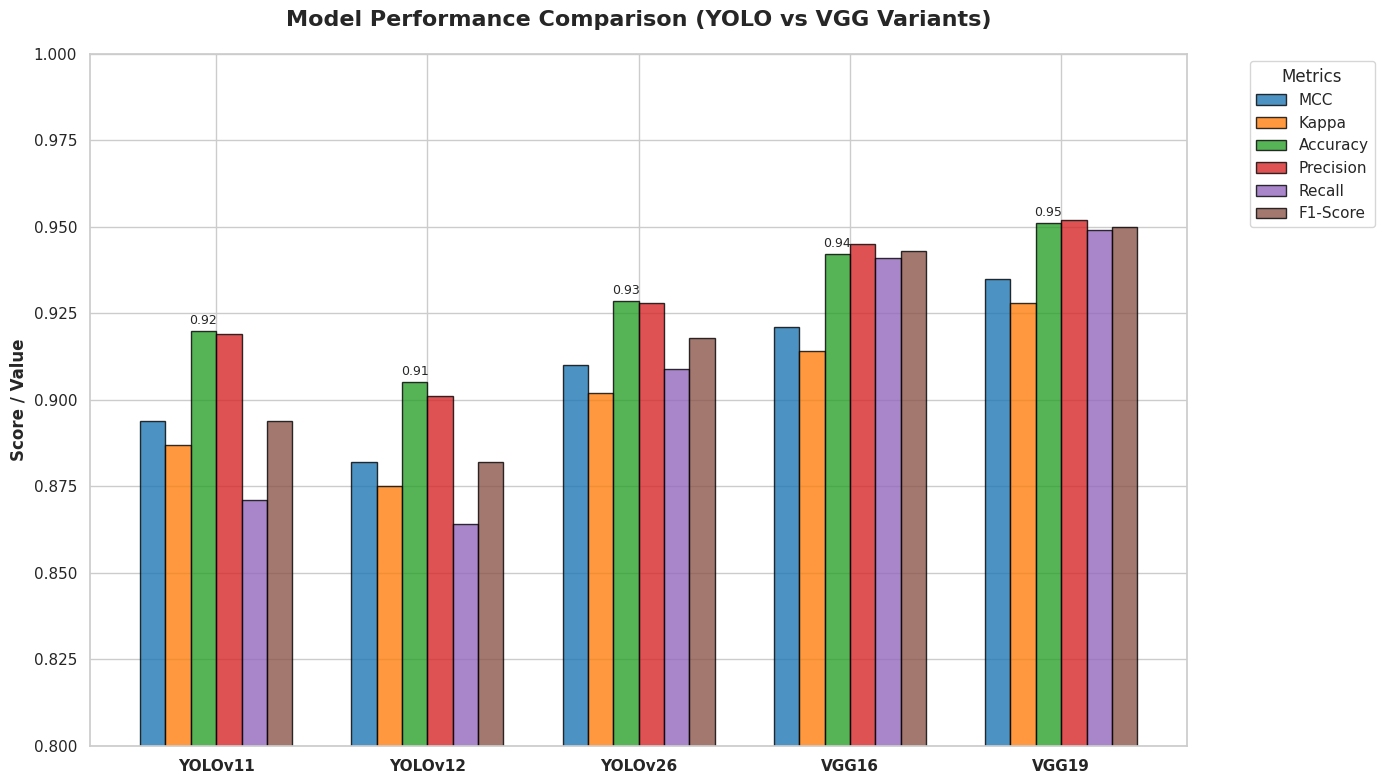

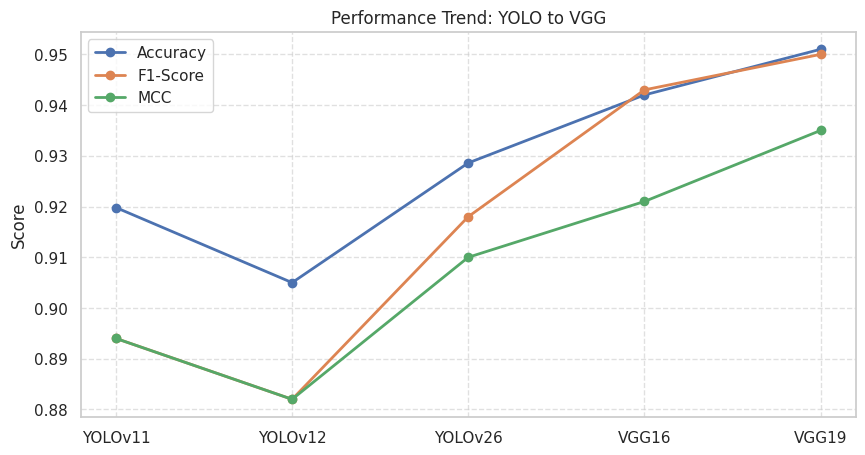

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# 1. Create the Dataset
data = {
    'Models': ['YOLOv11', 'YOLOv12', 'YOLOv26', 'VGG16', 'VGG19'],
    'MCC': [0.894, 0.882, 0.910, 0.921, 0.935],
    'Kappa': [0.887, 0.875, 0.902, 0.914, 0.928],
    'Accuracy': [0.9198, 0.9050, 0.9286, 0.9420, 0.9510], # Converted to decimal
    'Precision': [0.919, 0.901, 0.928, 0.945, 0.952],
    'Recall': [0.871, 0.864, 0.909, 0.941, 0.949],
    'F1-Score': [0.894, 0.882, 0.918, 0.943, 0.950]
}

df = pd.DataFrame(data)

# 2. Set Plot Style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# 3. Create Grouped Bar Chart
metrics = ['MCC', 'Kappa', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(df['Models']))  # Label locations
width = 0.12  # Width of the bars

fig, ax = plt.subplots(figsize=(14, 8))

# Color Palette
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i, metric in enumerate(metrics):
    offset = (i - len(metrics)/2) * width + width/2
    bars = ax.bar(x + offset, df[metric], width, label=metric, color=colors[i], edgecolor='black', alpha=0.8)

    # Optional: Add text labels on top of the best-performing model (VGG19)
    if metric == 'Accuracy':
        ax.bar_label(bars, padding=3, fmt='%.2f', fontsize=9)

# 4. Final Formatting
ax.set_ylabel('Score / Value', fontweight='bold')
ax.set_title('Model Performance Comparison (YOLO vs VGG Variants)', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(df['Models'], fontweight='bold')
ax.set_ylim(0.8, 1.0)  # Zoomed in to show differences clearly
ax.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 5. Optional: Individual Metric Trend Line (Good for Papers)
plt.figure(figsize=(10, 5))
for metric in ['Accuracy', 'F1-Score', 'MCC']:
    plt.plot(df['Models'], df[metric], marker='o', linewidth=2, label=metric)

plt.title('Performance Trend: YOLO to VGG')
plt.ylabel('Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()